In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/sleep-health-and-lifestyle-dataset/Sleep_health_and_lifestyle_dataset.csv


In [2]:
df1=pd.read_csv('/kaggle/input/sleep-health-and-lifestyle-dataset/Sleep_health_and_lifestyle_dataset.csv')
df1

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
...,...,...,...,...,...,...,...,...,...,...,...,...,...
369,370,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
370,371,Female,59,Nurse,8.0,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
371,372,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
372,373,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
print('COLUMNS OF DATASET-1=', df1.columns)
print("size of the dataset-1 =",df1.shape)


COLUMNS OF DATASET-1= Index(['Person ID', 'Gender', 'Age', 'Occupation', 'Sleep Duration',
       'Quality of Sleep', 'Physical Activity Level', 'Stress Level',
       'BMI Category', 'Blood Pressure', 'Heart Rate', 'Daily Steps',
       'Sleep Disorder'],
      dtype='object')
size of the dataset-1 = (374, 13)


In [4]:
print("Descriptive Statistics for Dataset 1:")
print(df1.describe())

Descriptive Statistics for Dataset 1:
        Person ID         Age  Sleep Duration  Quality of Sleep  \
count  374.000000  374.000000      374.000000        374.000000   
mean   187.500000   42.184492        7.132086          7.312834   
std    108.108742    8.673133        0.795657          1.196956   
min      1.000000   27.000000        5.800000          4.000000   
25%     94.250000   35.250000        6.400000          6.000000   
50%    187.500000   43.000000        7.200000          7.000000   
75%    280.750000   50.000000        7.800000          8.000000   
max    374.000000   59.000000        8.500000          9.000000   

       Physical Activity Level  Stress Level  Heart Rate   Daily Steps  
count               374.000000    374.000000  374.000000    374.000000  
mean                 59.171123      5.385027   70.165775   6816.844920  
std                  20.830804      1.774526    4.135676   1617.915679  
min                  30.000000      3.000000   65.000000   3000.00

In [5]:
#missing values in the datasets
print("Missing values in Dataset 1:")
print(df1.isnull().sum())
# Removing duplicate rows
df1_cleaned = df1.drop_duplicates()

# Check if duplicates were removed
print("Duplicates in Dataset 1:", df1_cleaned.duplicated().sum())

Missing values in Dataset 1:
Person ID                    0
Gender                       0
Age                          0
Occupation                   0
Sleep Duration               0
Quality of Sleep             0
Physical Activity Level      0
Stress Level                 0
BMI Category                 0
Blood Pressure               0
Heart Rate                   0
Daily Steps                  0
Sleep Disorder             219
dtype: int64
Duplicates in Dataset 1: 0


In [6]:
# detected outliers using IQR
def detect_outliers(df, columns):
    outliers = {}
    for col in columns:
        
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        
        
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        outliers[col] = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    
    return outliers

numerical_columns_df1 = ['Age', 'Sleep Duration', 'Heart Rate', 'Daily Steps']  
outliers_df1 = detect_outliers(df1_cleaned, numerical_columns_df1)
print("\nOutliers in Dataset 1:")
for col, outliers_data in outliers_df1.items():
    print(f"Outliers in {col}:")
    print(outliers_data)


Outliers in Dataset 1:
Outliers in Age:
Empty DataFrame
Columns: [Person ID, Gender, Age, Occupation, Sleep Duration, Quality of Sleep, Physical Activity Level, Stress Level, BMI Category, Blood Pressure, Heart Rate, Daily Steps, Sleep Disorder]
Index: []
Outliers in Sleep Duration:
Empty DataFrame
Columns: [Person ID, Gender, Age, Occupation, Sleep Duration, Quality of Sleep, Physical Activity Level, Stress Level, BMI Category, Blood Pressure, Heart Rate, Daily Steps, Sleep Disorder]
Index: []
Outliers in Heart Rate:
     Person ID  Gender  Age            Occupation  Sleep Duration  \
3            4    Male   28  Sales Representative             5.9   
4            5    Male   28  Sales Representative             5.9   
5            6    Male   28     Software Engineer             5.9   
6            7    Male   29               Teacher             6.3   
16          17  Female   29                 Nurse             6.5   
18          19  Female   29                 Nurse            

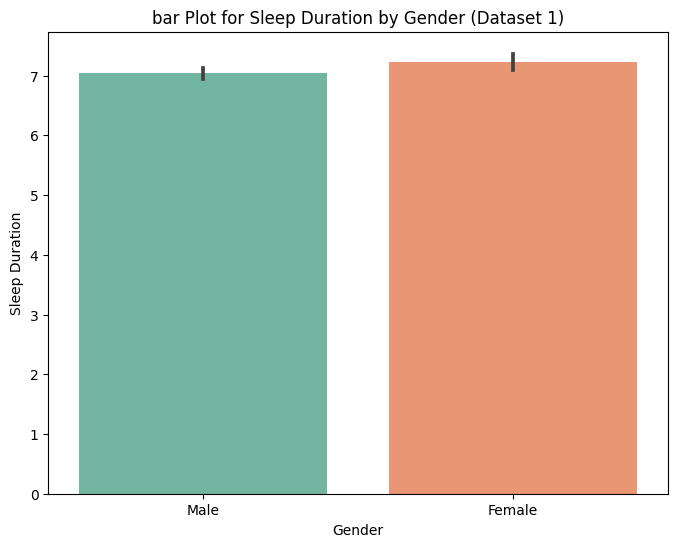

In [7]:

plt.figure(figsize=(8, 6))
sns.barplot(x='Gender', y='Sleep Duration', data=df1_cleaned, palette='Set2')
plt.title("bar Plot for Sleep Duration by Gender (Dataset 1)")
plt.show()


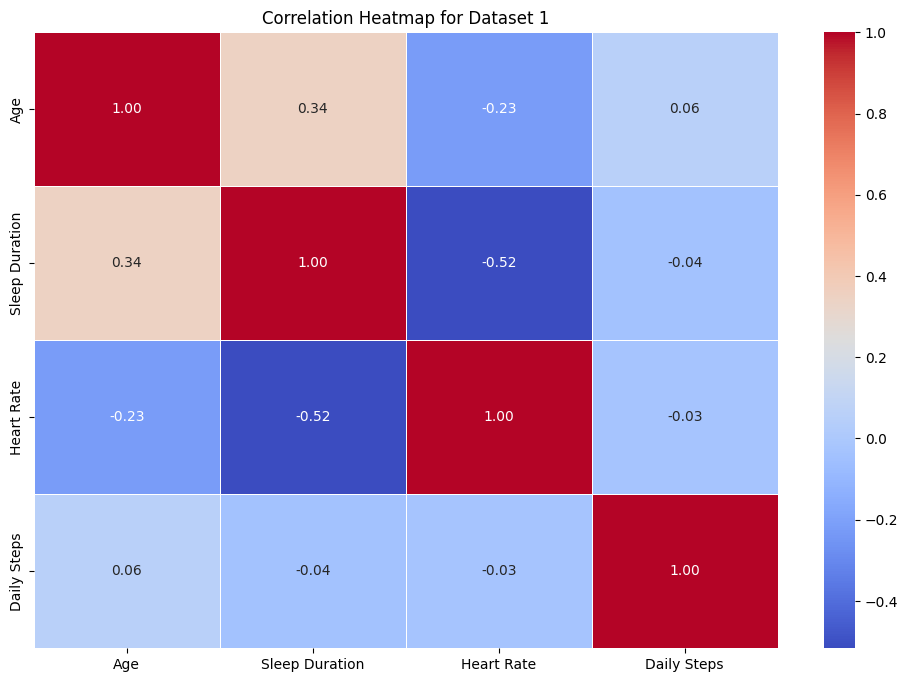

In [8]:
# Heatmap for Correlation Matrix
correlation_matrix_df1 = df1_cleaned[numerical_columns_df1].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix_df1, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title("Correlation Heatmap for Dataset 1")
plt.show()

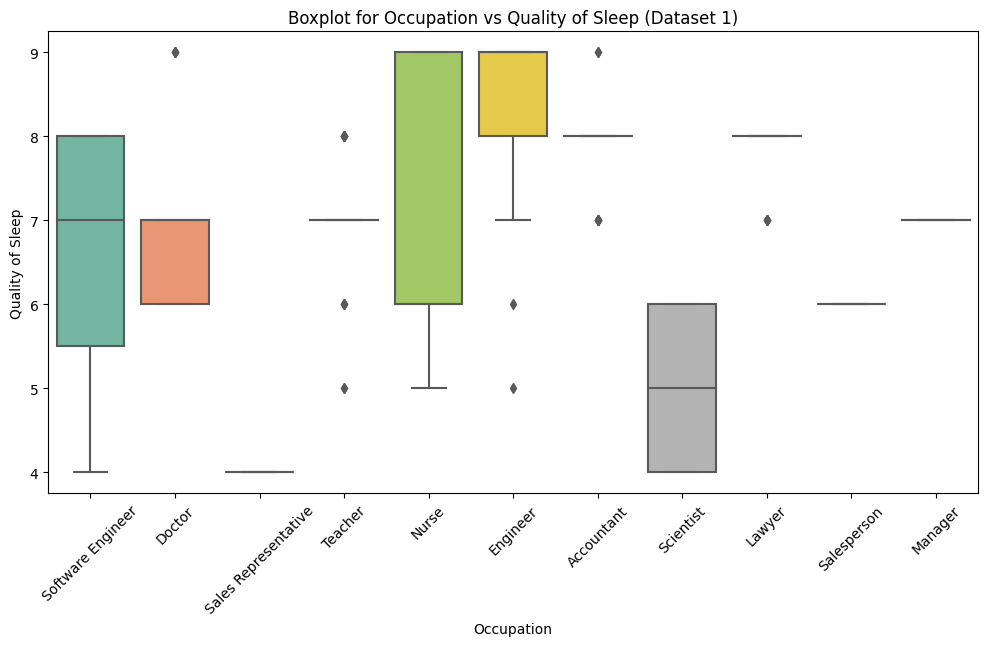

In [10]:
#  Boxplot for Occupation vs Quality of Sleep
plt.figure(figsize=(12, 6))
sns.boxplot(x='Occupation', y='Quality of Sleep', data=df1_cleaned, palette='Set2')
plt.xticks(rotation=45)  
plt.title("Boxplot for Occupation vs Quality of Sleep (Dataset 1)")
plt.xlabel("Occupation")
plt.ylabel("Quality of Sleep")
plt.show()

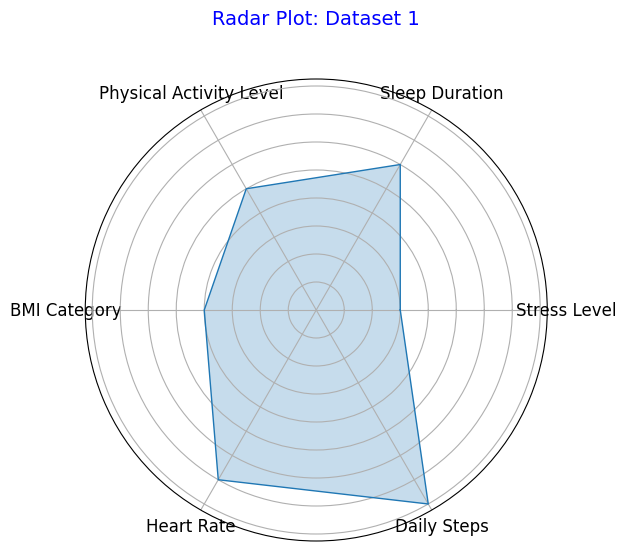

In [11]:
# Sample categories and data (ensure that both have the same length)
categories = ['Stress Level', 'Sleep Duration', 'Physical Activity Level', 'BMI Category', 'Heart Rate', 'Daily Steps']
# Sample data for each category (make sure the data length matches the number of categories)
data = [3, 6, 5, 4, 7, 8]  # For example, these should match the number of categories (6 in this case)

# Ensure that both categories and data have the same length
assert len(categories) == len(data), "Categories and Data must have the same length!"

# Radar chart setup
angles = np.linspace(0, 2 * np.pi, len(categories), endpoint=False).tolist()

# Close the plot by appending the first value to the end
data += data[:1]
angles += angles[:1]

# Create the radar plot
fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))

# Plot the data
ax.plot(angles, data, linewidth=1, linestyle='solid', label='Dataset 1')

# Fill the area under the plot
ax.fill(angles, data, alpha=0.25)

# Set labels for each axis (category names)
ax.set_yticklabels([])
ax.set_xticks(angles[:-1])  # Remove the last angle to prevent overlap
ax.set_xticklabels(categories, fontsize=12, ha='center')

# Title and show the plot
plt.title("Radar Plot: Dataset 1", size=14, color='blue', y=1.1)
plt.show()

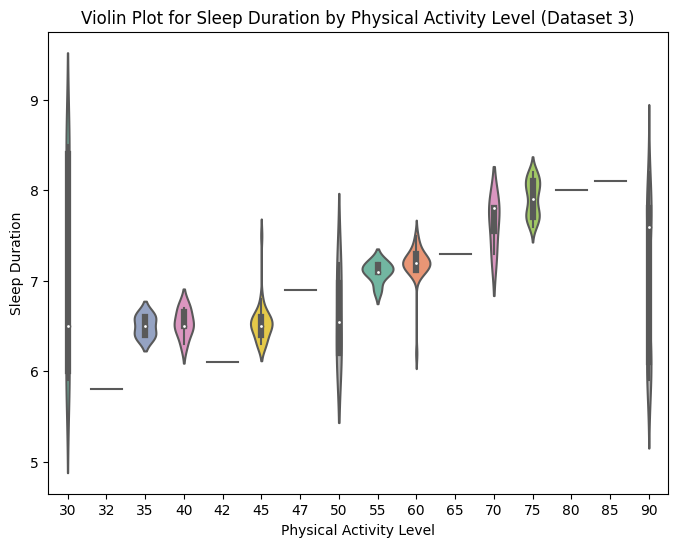

In [13]:
plt.figure(figsize=(8, 6))
sns.violinplot(x='Physical Activity Level', y='Sleep Duration', data=df1_cleaned, palette='Set2')
plt.title("Violin Plot for Sleep Duration by Physical Activity Level (Dataset 3)")
plt.show()

/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


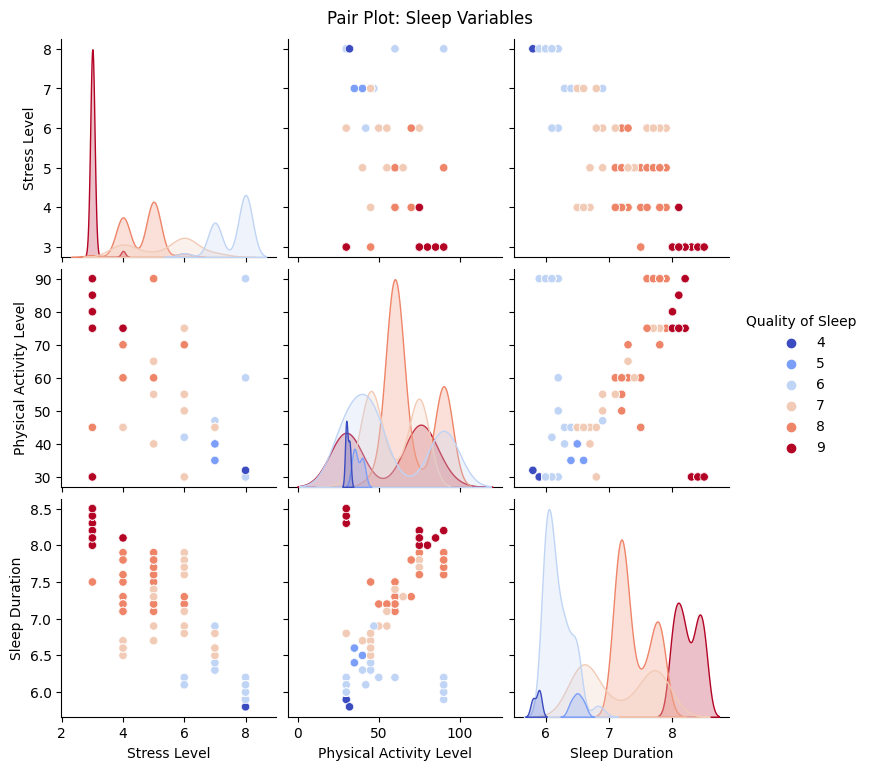

In [14]:
sns.pairplot(
    df1[['Stress Level', 'Physical Activity Level', 'Sleep Duration', 'Quality of Sleep']],
    hue='Quality of Sleep',
    palette='coolwarm'
)
plt.suptitle('Pair Plot: Sleep Variables', y=1.02)
plt.show()

In [15]:
import statsmodels.api as sm

X = df1['Stress Level']
y = df1['Quality of Sleep']

# Add constant for regression intercept
X = sm.add_constant(X)

# Fit the model
model = sm.OLS(y, X).fit()

# Summary of the model
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:       Quality of Sleep   R-squared:                       0.808
Model:                            OLS   Adj. R-squared:                  0.807
Method:                 Least Squares   F-statistic:                     1563.
Date:                Sun, 05 Jan 2025   Prob (F-statistic):          2.88e-135
Time:                        08:57:10   Log-Likelihood:                -289.06
No. Observations:                 374   AIC:                             582.1
Df Residuals:                     372   BIC:                             590.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const           10.5774      0.087    121.678   

In [18]:
#preprocessing


from sklearn.model_selection import train_test_split

# For predicting 'Quality of Sleep'
X = df1[['Sleep Duration', 'Stress Level', 'Physical Activity Level', 'Daily Steps', 'BMI Category']]
y = df1['Quality of Sleep']  # Target variable

# Splitting the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [19]:
# Function to compute enhanced statistical measures
def compute_enhanced_statistics(df, dataset_name):
    print(f"\nEnhanced Statistical Measures for {dataset_name}:\n")
    numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns
    for col in numerical_cols:
        print(f"Column: {col}")
        print(f"  Mean: {df[col].mean()}")
        print(f"  Median: {df[col].median()}")
        print(f"  Mode: {df[col].mode()[0]}")
        print(f"  Variance: {df[col].var()}")
        print(f"  Standard Deviation: {df[col].std()}")
        print(f"  Minimum: {df[col].min()}")
        print(f"  Maximum: {df[col].max()}")
        print(f"  Range: {df[col].max() - df[col].min()}")
        print(f"  Skewness: {df[col].skew()}")
        print(f"  Kurtosis: {df[col].kurt()}")
        print()

# Compute for Dataset-1
compute_enhanced_statistics(df1, "Dataset-1")


Enhanced Statistical Measures for Dataset-1:

Column: Person ID
  Mean: 187.5
  Median: 187.5
  Mode: 1
  Variance: 11687.5
  Standard Deviation: 108.10874155219827
  Minimum: 1
  Maximum: 374
  Range: 373
  Skewness: 0.0
  Kurtosis: -1.1999999999999997

Column: Age
  Mean: 42.18449197860963
  Median: 43.0
  Mode: 43
  Variance: 75.22324411119554
  Standard Deviation: 8.673133465547243
  Minimum: 27
  Maximum: 59
  Range: 32
  Skewness: 0.2572221422742844
  Kurtosis: -0.9097795476259583

Column: Sleep Duration
  Mean: 7.132085561497325
  Median: 7.2
  Mode: 7.2
  Variance: 0.6330696334102738
  Standard Deviation: 0.7956567308898189
  Minimum: 5.8
  Maximum: 8.5
  Range: 2.7
  Skewness: 0.037554389846484834
  Kurtosis: -1.286506239045075

Column: Quality of Sleep
  Mean: 7.31283422459893
  Median: 7.0
  Mode: 8
  Variance: 1.4327034737853224
  Standard Deviation: 1.196955919733606
  Minimum: 4
  Maximum: 9
  Range: 5
  Skewness: -0.20744763173836073
  Kurtosis: -0.7482755418548042

Col

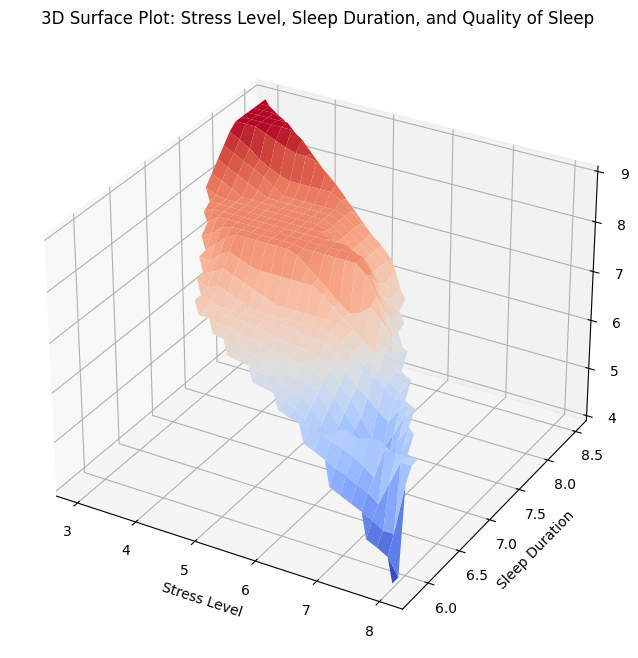

In [23]:
# 3D Surface Plot (Dataset 1): Stress Level vs Quality of Sleep vs Sleep Duration
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Variables for plotting
x2 = df1_cleaned['Stress Level']
y2 = df1_cleaned['Sleep Duration']
z2 = df1_cleaned['Quality of Sleep']

# Create meshgrid for surface plotting
x_grid, y_grid = np.meshgrid(np.linspace(x2.min(), x2.max(), 30), np.linspace(y2.min(), y2.max(), 30))

# Interpolate to get a smooth surface
from scipy.interpolate import griddata
z_grid = griddata((x2, y2), z2, (x_grid, y_grid), method='linear')

# Surface plot
ax.plot_surface(x_grid, y_grid, z_grid, cmap='coolwarm', edgecolor='none')

# Labels and title
ax.set_xlabel('Stress Level')
ax.set_ylabel('Sleep Duration')
ax.set_zlabel('Quality of Sleep')
ax.set_title('3D Surface Plot: Stress Level, Sleep Duration, and Quality of Sleep')

plt.show()

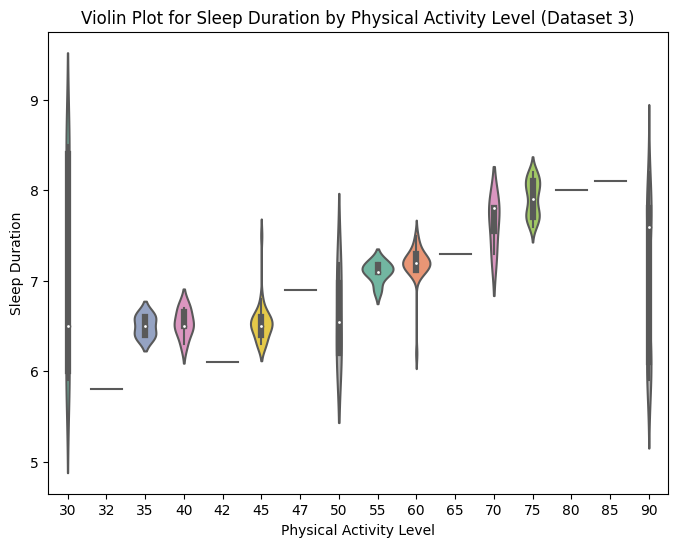

In [24]:
plt.figure(figsize=(8, 6))
sns.violinplot(x='Physical Activity Level', y='Sleep Duration', data=df1_cleaned, palette='Set2')
plt.title("Violin Plot for Sleep Duration by Physical Activity Level (Dataset 3)")
plt.show()

In [27]:
from mpl_toolkits.mplot3d import Axes3D
from scipy.interpolate import griddata
from sklearn.preprocessing import LabelEncoder
from matplotlib import cm
from sklearn.preprocessing import LabelEncoder
from scipy.stats import f_oneway

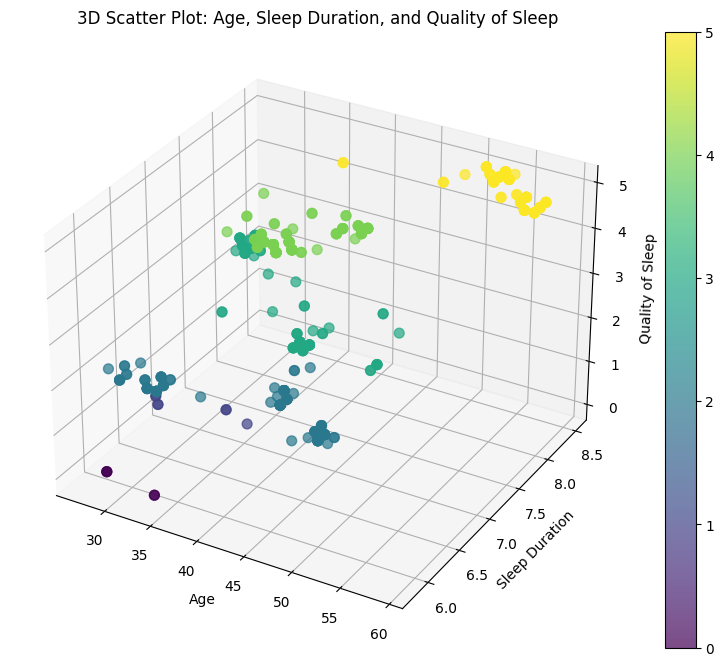

In [28]:
# Encoding categorical data for better visualization
label_encoder = LabelEncoder()

# Encoding 'Quality of Sleep' in Dataset 1 (Numerical for plotting purposes)
df1_cleaned['Quality of Sleep'] = label_encoder.fit_transform(df1_cleaned['Quality of Sleep'])

# Encoding 'Sleep Disorder' in Dataset 3 (Encoded for better visualization)
df1_cleaned['Sleep Disorder'] = label_encoder.fit_transform(df1_cleaned['Sleep Disorder'])
# 3D Scatter Plot (Dataset 1): Sleep Duration vs Quality of Sleep vs Age
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Variables for plotting
x1 = df1_cleaned['Age']
y1 = df1_cleaned['Sleep Duration']
z1 = df1_cleaned['Quality of Sleep']

# Scatter plot
sc = ax.scatter(x1, y1, z1, c=z1, cmap=cm.viridis, s=50, alpha=0.7)

# Labels and title
ax.set_xlabel('Age')
ax.set_ylabel('Sleep Duration')
ax.set_zlabel('Quality of Sleep')
ax.set_title('3D Scatter Plot: Age, Sleep Duration, and Quality of Sleep')

# Color bar
fig.colorbar(sc)

plt.show()